In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import numpy as np
import pandas as pd

GEOJSON = '/Users/al3792/Documents_Local/MacroEnergy.jl/ExampleSystems/gadm36_CHN_1.json'

In [32]:
gdf = gpd.read_file(GEOJSON)

# Rename GeoJSON names to match model province names
rename_map = {
    "Nei Mongol":     "Innermongolia",
    "Ningxia Hui":    "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
    "Xizang":         "Tibet",
}
gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

In [33]:
cap_bfbof    = pd.read_csv('capacity_steel_bfbof.csv').set_index('province')
cap_eaf      = pd.read_csv('capacity_steel_eaf.csv').set_index('province')
cap_cement   = pd.read_csv('capacity_cement.csv').set_index('province')
cap_aluminum = pd.read_csv('capacity_aluminum.csv').set_index('province')
dem_steel    = pd.read_csv('demand_steel.csv').set_index('province')
dem_cement   = pd.read_csv('demand_cement.csv').set_index('province')
scrap_supply = pd.read_csv('scrap_supply_steel.csv').set_index('province')

In [34]:
def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14,10),
    title="",
    legend_sizes=None,
    capacity_unit="MW",
    scale_max=None,       # shared normalization max — pass same value to two plots for equal scale
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    # --- 1. PROJECT TO WEB-MERCATOR TO FIX DISTORTION ---
    gdf_proj = gdf.to_crs(epsg=3857)

    # Merge data — left join keeps all provinces on the map (NaN capacity → 0)
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True, how="left")
    gdf_proj[categories] = gdf_proj[categories].fillna(0)

    # Compute projected centroids (in meters → circles stay circles)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    # Compute dynamic radii
    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = scale_max if scale_max is not None else (gdf_proj["total_value"].max() or 1)
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000
    # ^ 80 km radius for the largest pie — adjust scale if needed

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    # Draw pies
    for _, row in gdf_proj.iterrows():

        cx, cy, r = row["cx"], row["cy"], row["radius"]

        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue

        angles = np.cumsum(vals) / total * 360
        prev_angle = 0

        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy),
                r=r,
                theta1=prev_angle,
                theta2=angle,
                facecolor=colors[cat],
                edgecolor="none",
                alpha=1.0,
                zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    # Draw province boundaries underneath
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="black", linewidth=0.7, zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.7, color="black", zorder=1)
    plt.rcParams['lines.antialiased'] = True

    # --- Size legend ---
    if legend_sizes is not None and len(legend_sizes) > 0:
        legend_radii = [(s / max_total) * pie_scale * 80_000 for s in legend_sizes]
        sizes_and_radii = sorted(zip(legend_sizes, legend_radii))  # ascending by size

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        plot_width  = xlim[1] - xlim[0]
        plot_height = ylim[1] - ylim[0]

        pad_x = plot_width  * 0.02
        pad_y = plot_height * 0.02
        max_r = max(legend_radii)
        legend_cx = xlim[0] + pad_x + max_r

        # Stack circles from bottom (largest) to top (smallest), bottom-edge aligned per circle
        y = ylim[0] + pad_y
        for size, radius in sizes_and_radii:
            cy_legend = y + radius
            circle = Circle(
                (legend_cx, cy_legend), radius,
                facecolor="white", edgecolor="#555555",
                linewidth=1.2, zorder=2000
            )
            ax.add_patch(circle)
            label = f"{size:,.0f} {capacity_unit}"
            ax.text(
                legend_cx + max_r + pad_x * 0.6,
                cy_legend,
                label,
                va="center", ha="left", fontsize=9, zorder=2001
            )
            y += radius * 2 + pad_y * 0.4

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()

In [51]:
STEEL_COLORS      = {"BF-BOF": "#1f77b4", "Scrap EAF": "#38a938"}
CEMENT_COLORS     = {"Traditional Cement": "#e15759"}
ALUM_COLORS       = {"Aluminum Smelting": "#bbbbb2"}
SCRAP_COLORS      = {"Scrap Supply": "#9467bd"}
DEM_STEEL_COLORS  = {"Steel Demand": "#1f77b4"}
DEM_CEMENT_COLORS = {"Cement Demand": "#e15759"}

In [52]:
# Shared scale maxes so capacity and demand circles are on the same scale per commodity
steel_cap_df = cap_bfbof.rename(columns={'existing_capacity_mt_yr': 'BF-BOF'}).join(
    cap_eaf.rename(columns={'existing_capacity_mt_yr': 'Scrap EAF'}), how='outer'
).fillna(0)
steel_dem_df = dem_steel.rename(columns={'annual_demand_mt_yr': 'Steel Demand'})
cement_cap_df = cap_cement.rename(columns={'existing_capacity_mt_yr': 'Traditional Cement'})
cement_dem_df = dem_cement.rename(columns={'annual_demand_mt_yr': 'Cement Demand'})

STEEL_SCALE_MAX  = max(steel_cap_df.sum(axis=1).max(), steel_dem_df.sum(axis=1).max())
CEMENT_SCALE_MAX = max(cement_cap_df.sum(axis=1).max(), cement_dem_df.sum(axis=1).max())

print(f"Steel  scale max: {STEEL_SCALE_MAX:.1f} MT/yr")
print(f"Cement scale max: {CEMENT_SCALE_MAX:.1f} MT/yr")

Steel  scale max: 224.2 MT/yr
Cement scale max: 305.2 MT/yr


## Steel Existing Capacity

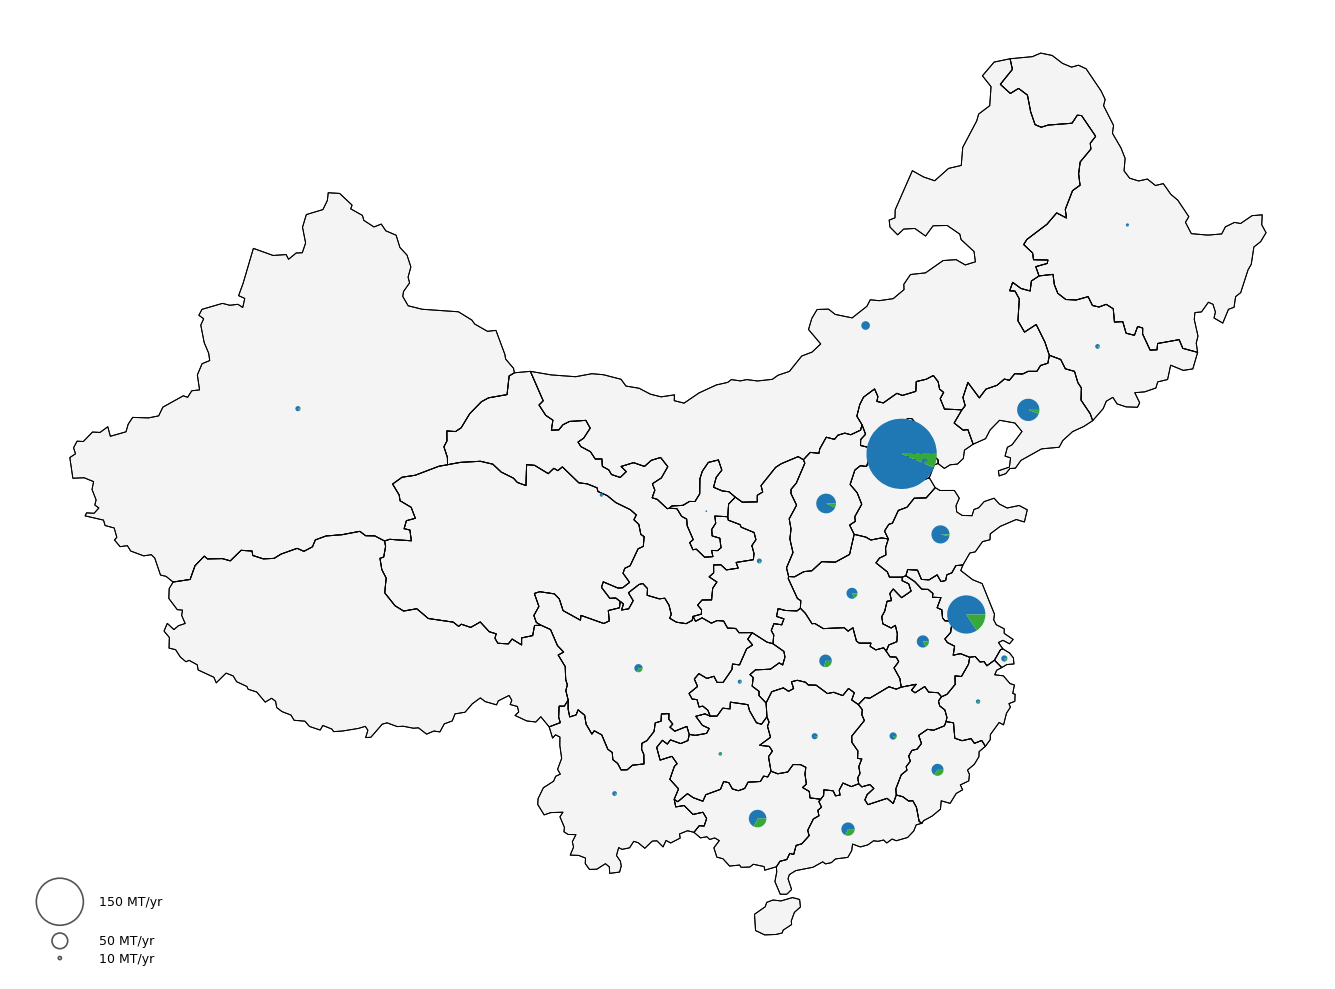

In [53]:
plot_province_pies(
    gdf, steel_cap_df,
    categories=["BF-BOF", "Scrap EAF"],
    colors=STEEL_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[10, 50, 150],
    capacity_unit="MT/yr",
    scale_max=STEEL_SCALE_MAX,
)

## Cement Existing Capacity

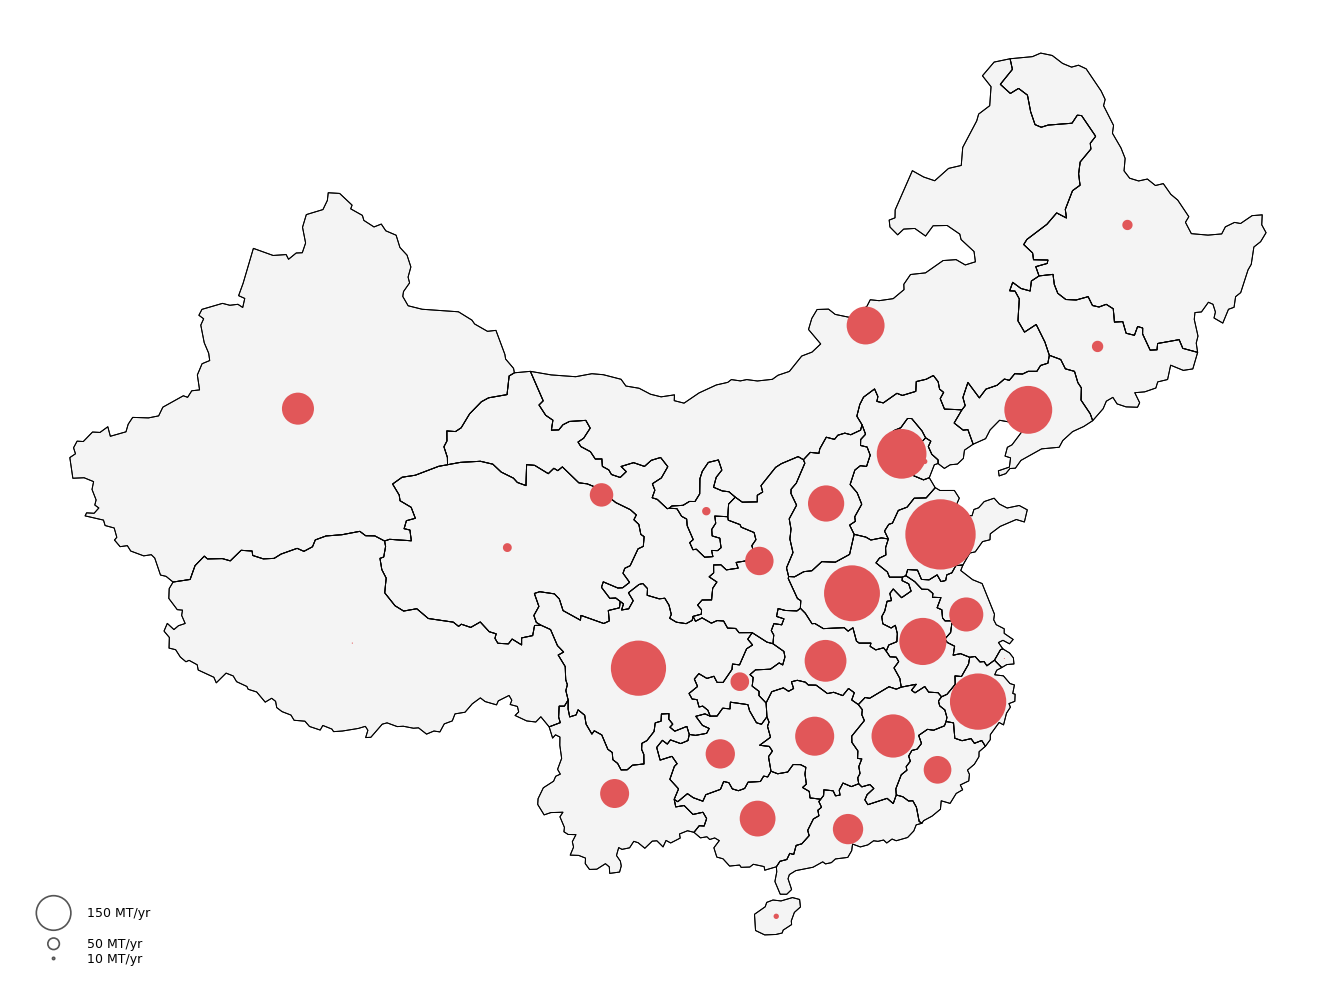

In [54]:
plot_province_pies(
    gdf, cement_cap_df,
    categories=["Traditional Cement"],
    colors=CEMENT_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[10, 50, 150],
    capacity_unit="MT/yr",
    scale_max=CEMENT_SCALE_MAX,
)

## Aluminum Existing Capacity

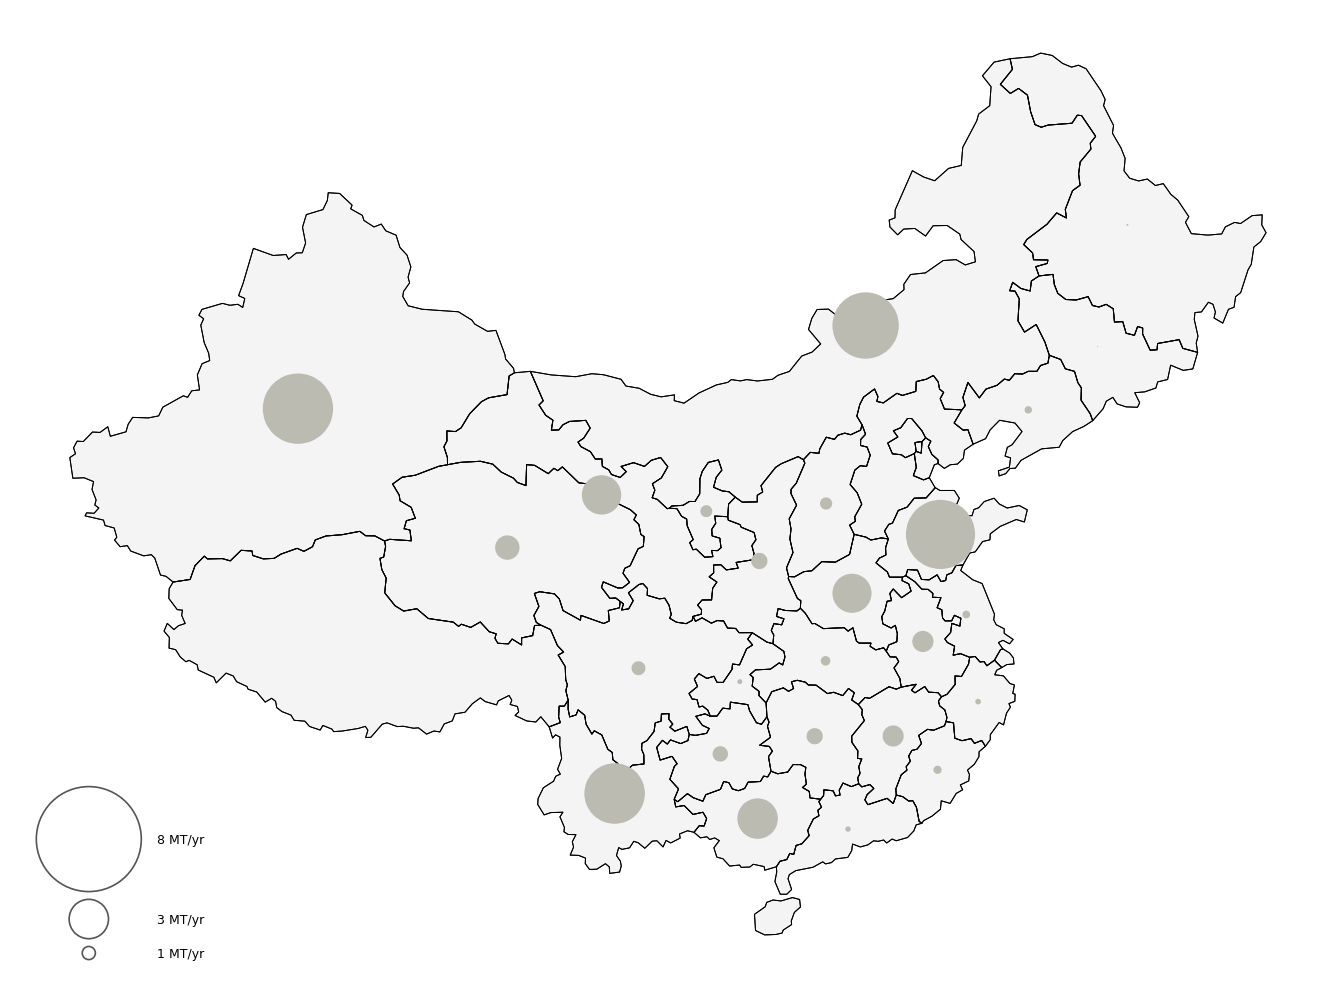

In [55]:
aluminum_cap_df = cap_aluminum.rename(columns={'existing_capacity_mt_yr': 'Aluminum Smelting'})

plot_province_pies(
    gdf, aluminum_cap_df,
    categories=["Aluminum Smelting"],
    colors=ALUM_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[1, 3, 8],
    capacity_unit="MT/yr",
)

## Steel Demand

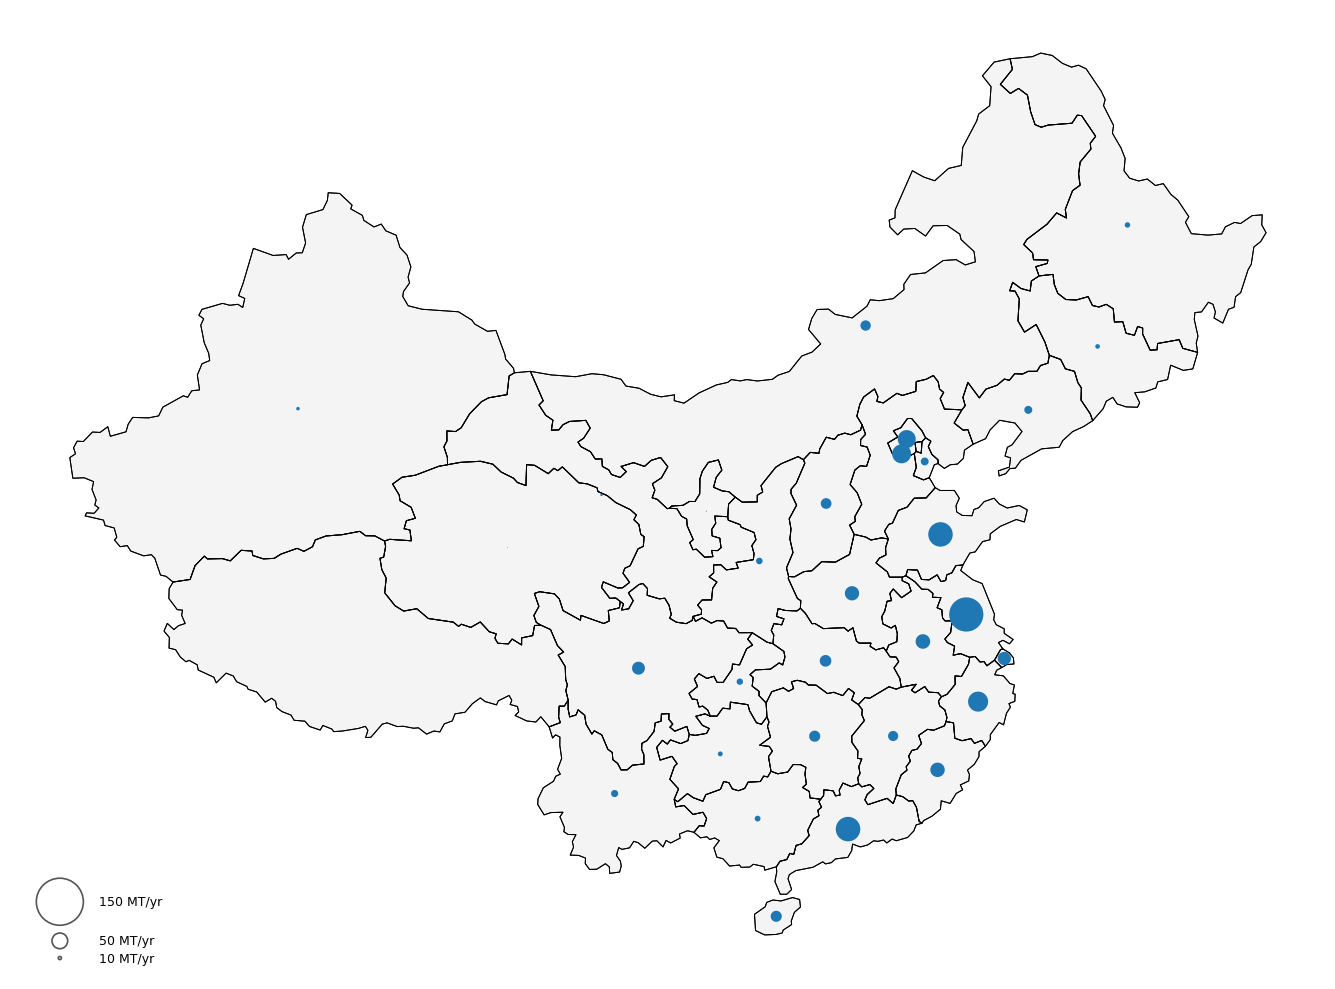

In [46]:
plot_province_pies(
    gdf, steel_dem_df,
    categories=["Steel Demand"],
    colors=DEM_STEEL_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[10, 50, 150],
    capacity_unit="MT/yr",
    scale_max=STEEL_SCALE_MAX,
)

## Cement Demand

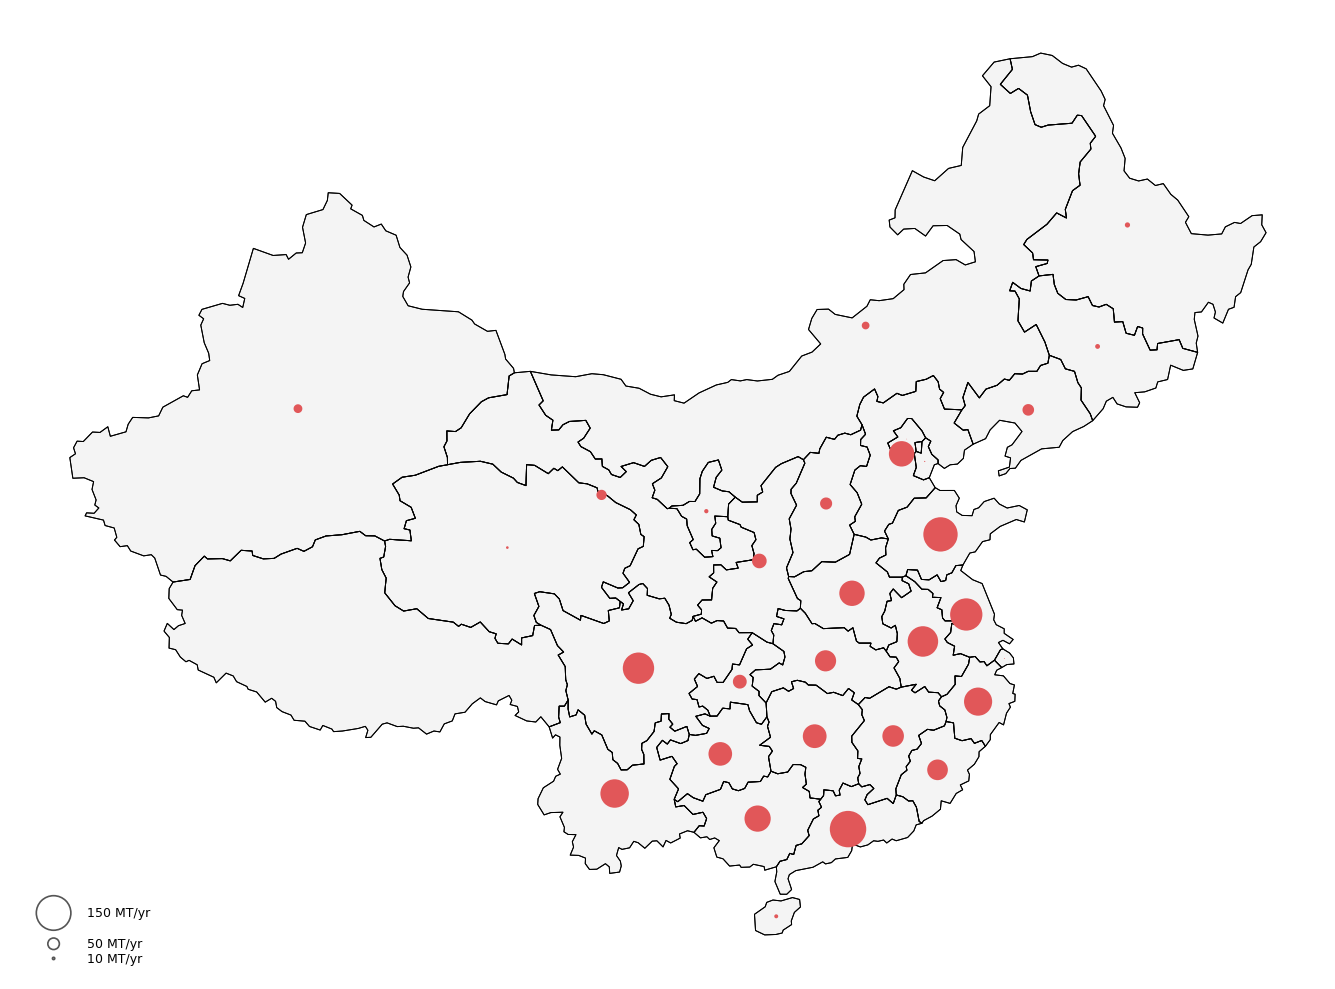

In [45]:
plot_province_pies(
    gdf, cement_dem_df,
    categories=["Cement Demand"],
    colors=DEM_CEMENT_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[10, 50, 150],
    capacity_unit="MT/yr",
    scale_max=CEMENT_SCALE_MAX,
)

## Steel Scrap Supply

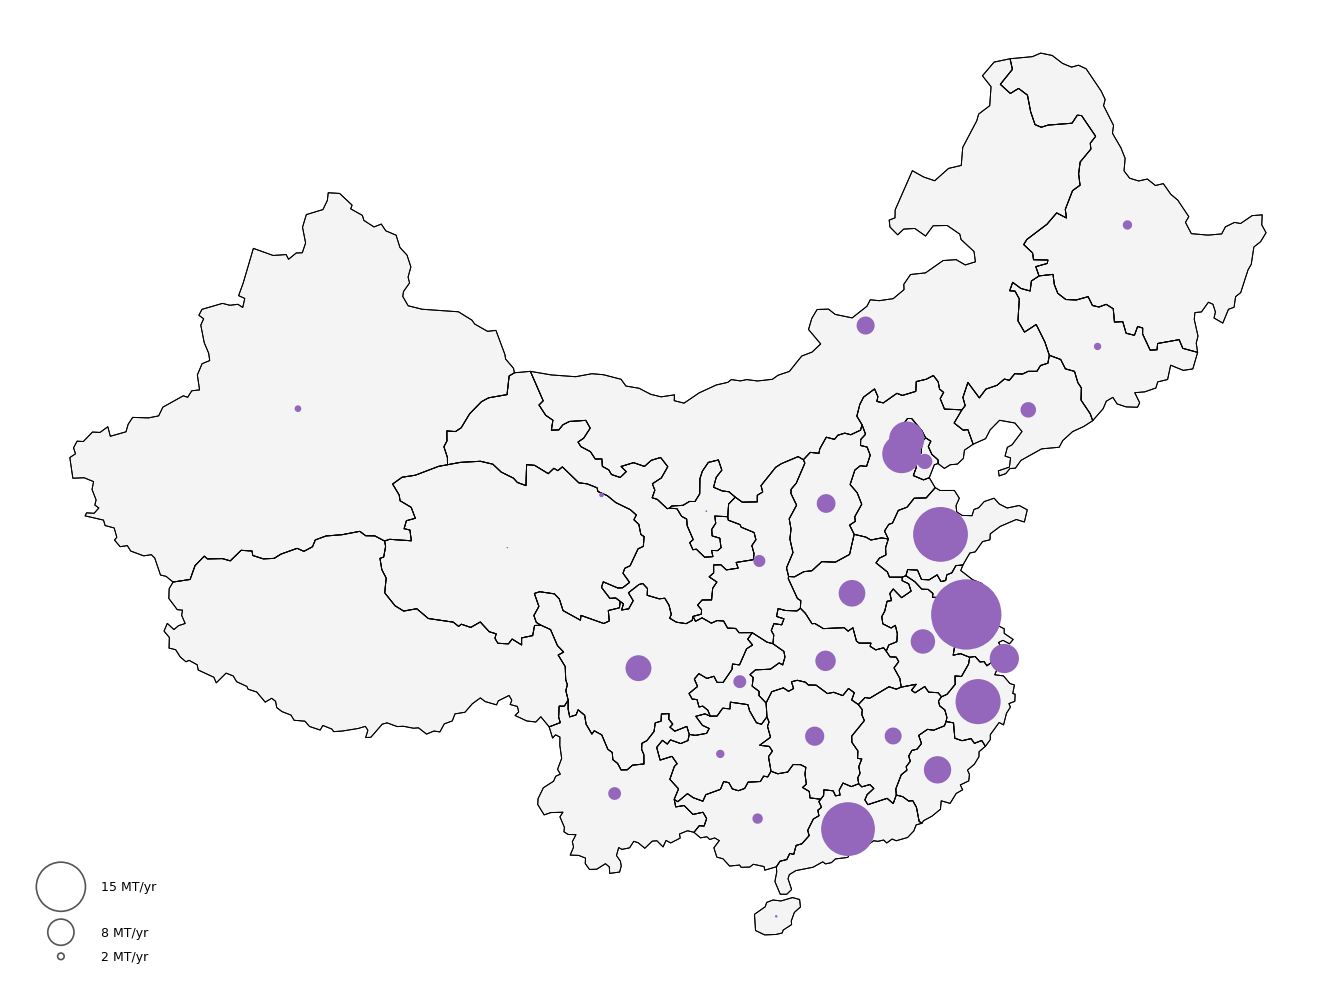

In [49]:
scrap_df = scrap_supply.rename(columns={'annual_scrap_supply_mt_yr': 'Scrap Supply'})

plot_province_pies(
    gdf, scrap_df,
    categories=["Scrap Supply"],
    colors=SCRAP_COLORS,
    pie_scale=2.5,
    title="",
    legend_sizes=[2, 8, 15],
    capacity_unit="MT/yr",
)